📏 Silhouette Score (UMAP): 0.3985


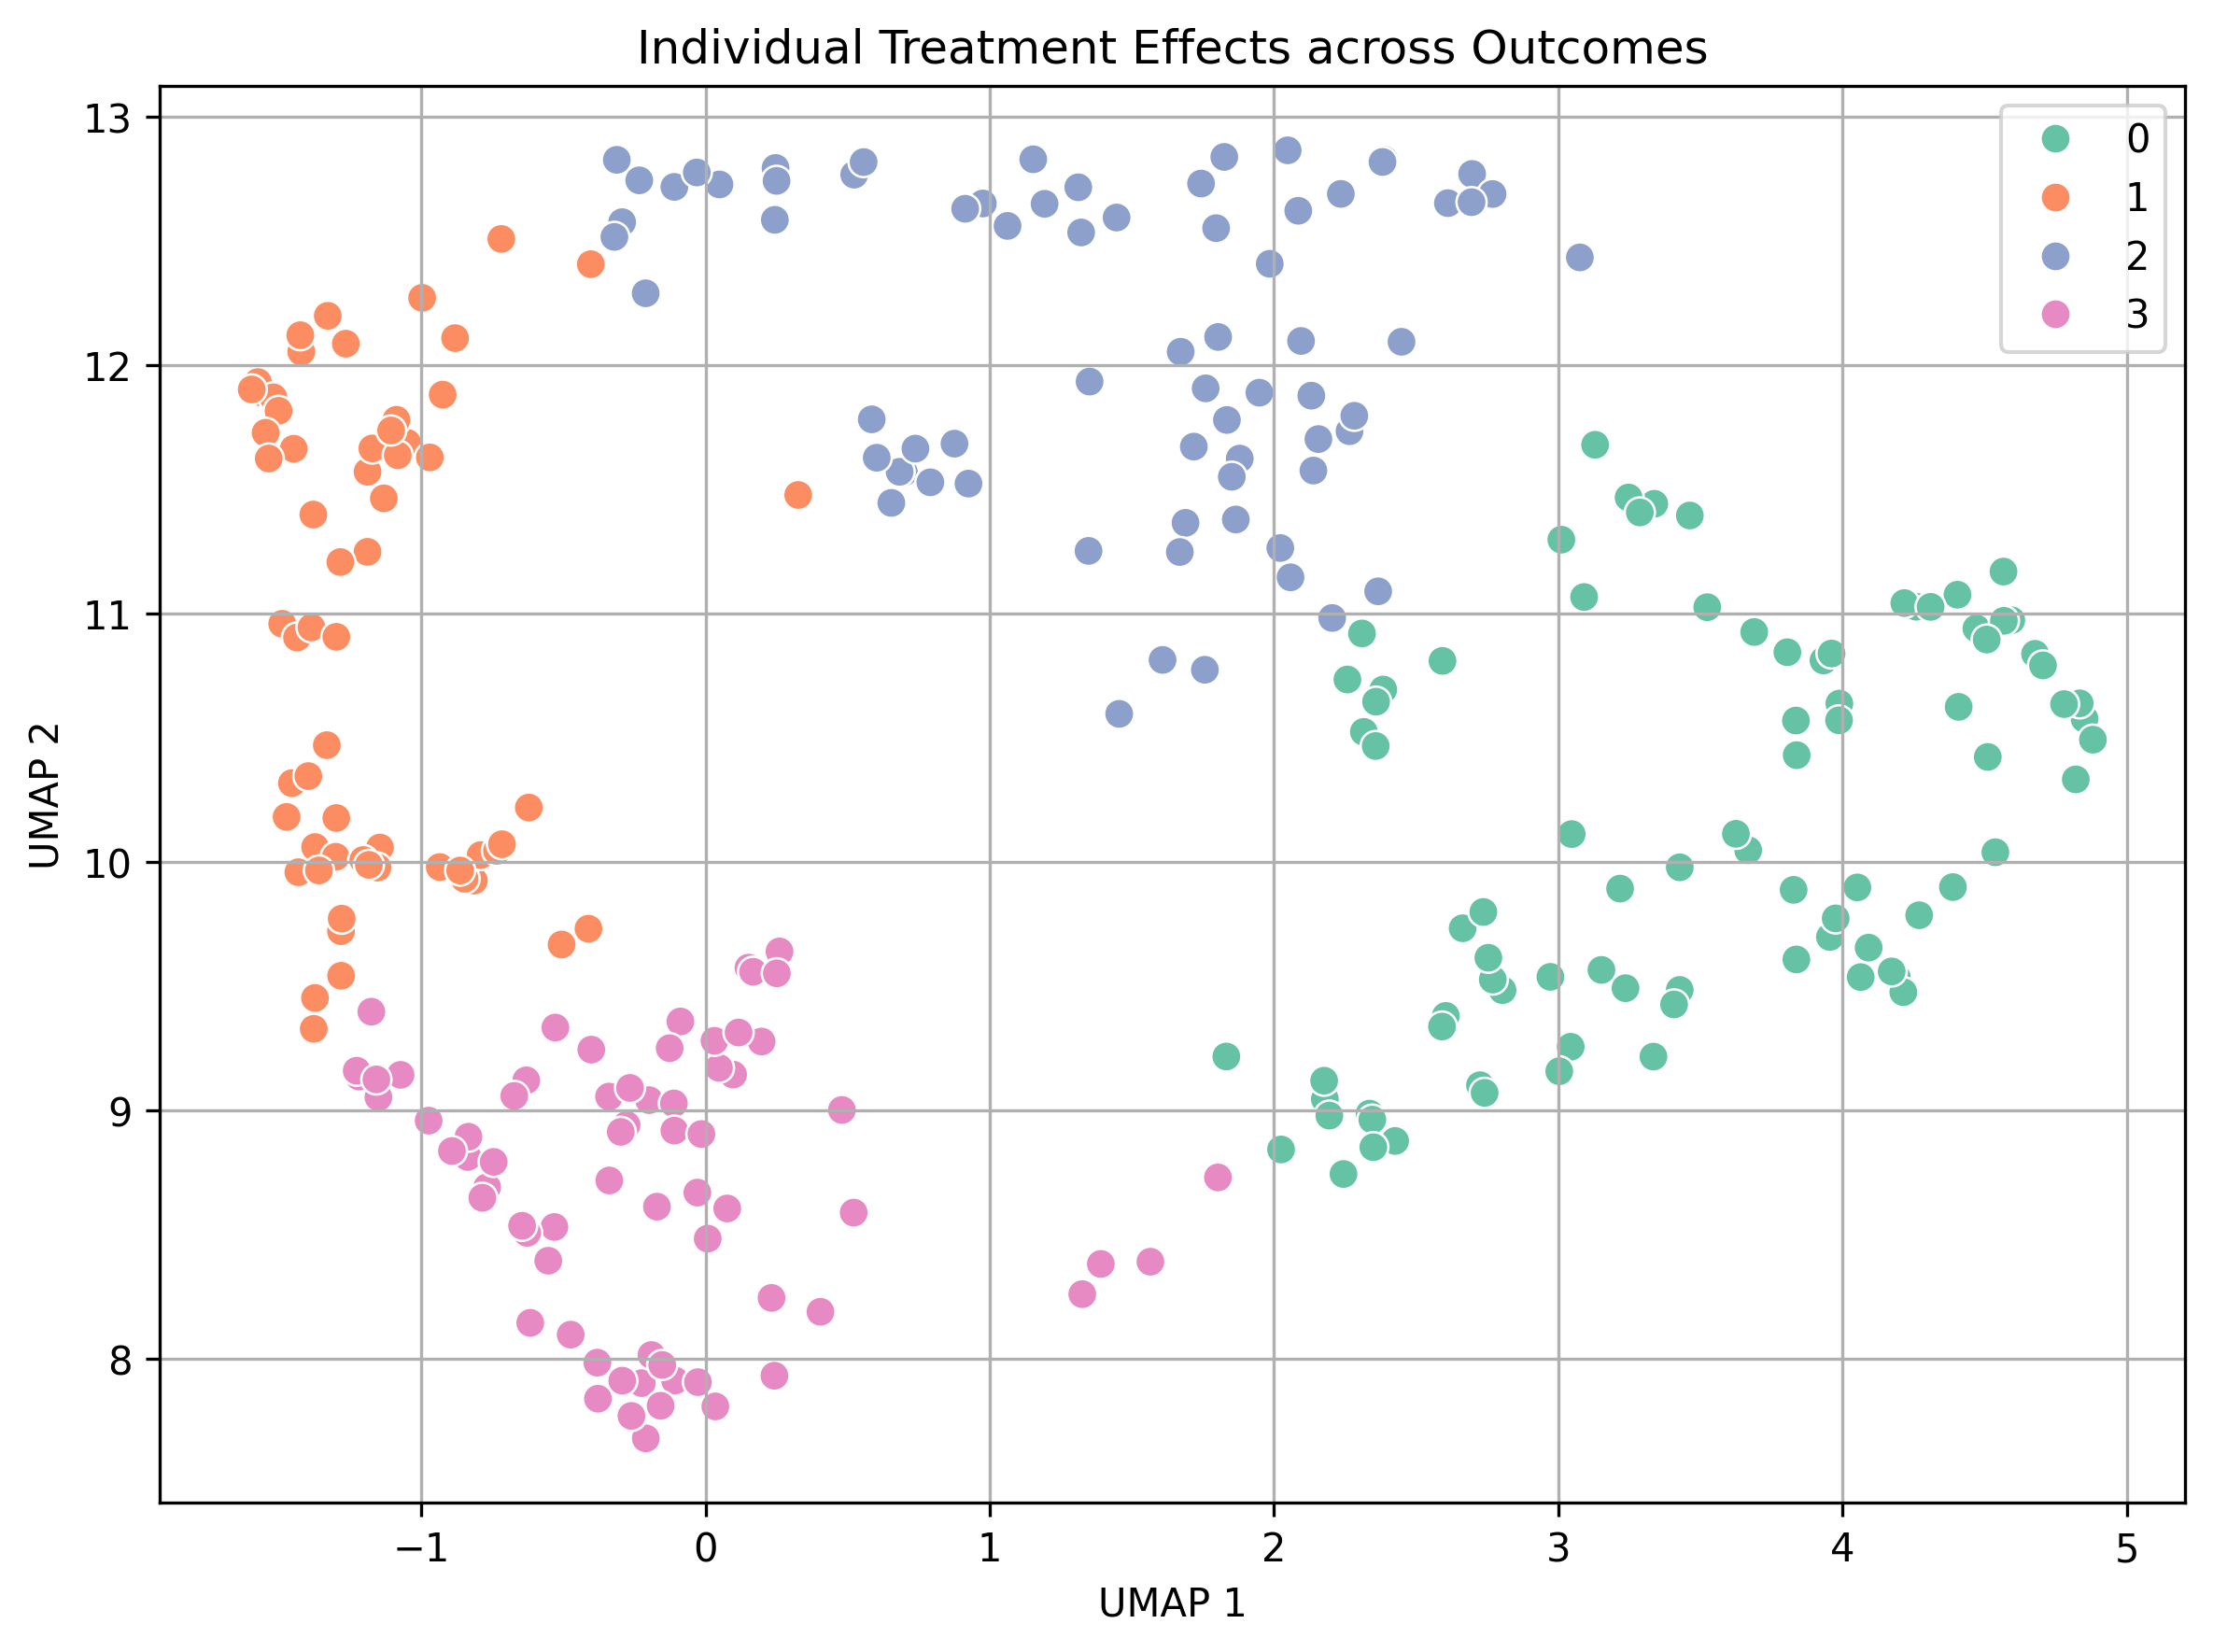

In [18]:
from modules.cluster import generate_cate_matrix, umap_cluster_cates, visualize_clusters, visualize_clusters_3d_plotly, plot_cate_tradeoff
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from modules.preprocess import load_and_clean_data, prepare_variables



# Step 1: prepare baseline
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, outcome_col='mrs_binary')  # any outcome will do, X is same

# Step 2: define CATE sources
cate_file_dict = {
    "mrs_binary": "cate_results/cate_results_mrs_binary.csv",
    "infarct_dch": "cate_results/cate_results_infarct_dch.csv",
    "vs_clin": "cate_results/cate_results_vs_clin.csv",
    "infection_dch": "cate_results/cate_results_infection_dch.csv",
    "gos_binary": "cate_results/cate_results_gos_binary.csv",
    "shunt_180": "cate_results/cate_results_shunt_180.csv",
}

# Step 3: build matrix
cate_matrix = generate_cate_matrix(X, cate_file_dict)


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer

import matplotlib.pyplot as plt
import seaborn as sns



# Step 4: UMAP-based cluster
X_umap, clusters, reducer, kmeans = umap_cluster_cates(cate_matrix, n_clusters=4)
# Step 5: Visualize
visualize_clusters(X_umap, clusters, method="UMAP")


In [19]:
df.columns

Index(['no', 'random', 'age', 'sex', 'height', 'weight', 'mrs_adm', 'gcs',
       'hh', 'sedation_adm', 'aneurysm_no', 'aneurysm_trt', 'infarct_trt',
       'hemorrhage_trt', 'infarct_dch', 'rehab_dch', 'barthel_dch',
       'rehab_barthel_dch', 'mrs_dch', 'rehab_score_180', 'barthel_180',
       'rehab_barthel_180', 'mrs_180', 'gos8_180', 'aneurysm_circulation',
       'aneurysm_location', 'aneurysm_size', 'hemorrh_before', 'paresis_adm',
       'aphasia_adm', 'loc_dch', 'infection_dch', 'gos8_dch',
       'dch_imag_modality', 'shunt_dch', 'shunt_180', 'nimodipine', 'statin',
       'mg', 'vs_clin', 'vs_angio_amount', 'vs_angio_trt_endo', 'query_180',
       'evd_mean', 'ld_mean', 'evd_total', 'ld_total', 'csf_total', 'tcd_max',
       'center_size', 'wfns', 'ct_ivh', 'ct_ich', 'ct_origfisher',
       'ct_modfisher', 'days_sah_trt', 'days_sah_trt_ct', 'days_sah_icu',
       'days_trt_icu', 'days_sah_ld', 'days_angio_vs', 'days_sah_dch',
       'days_sah_dch_imaging', 'days_sah_death',

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Attach cluster labels to dataframe
df['cluster'] = clusters

# List of continuous variables for median + IQR comparisons
continuous_vars = ['age', 'bmi', 'icp_high_mean']

# Binary variables
binary_vars = ['ct_ivh', 'ct_ich', 'paresis_adm', 'aphasia_adm', 'nimodipine', 'statin', 'mg']

print("\n📊 Median and IQR (25th–75th percentile) with Kruskal–Wallis P-values:\n")

def iqr(series):
    return np.percentile(series, 25), np.percentile(series, 75)

for var in continuous_vars:
    print(f"\n--- {var.upper()} ---")
    
    # Print median/IQR per cluster
    groups = []
    for c in sorted(df['cluster'].unique()):
        data = df[df['cluster'] == c][var].dropna()
        groups.append(data)
        median = np.median(data)
        q1, q3 = iqr(data)
        print(f"Cluster {c}: Median = {median:.2f}, IQR = ({q1:.2f}, {q3:.2f})")
    
    # Kruskal–Wallis H-test
    stat, pval = kruskal(*groups)
    print(f"Kruskal–Wallis P-value: {pval:.10f}")

print("\n📊 Binary Variable Frequencies, Percentages, and Chi-Square:\n")

from scipy.stats import chi2_contingency

for var in binary_vars:
    print(f"\n--- {var.upper()} ---")
    freq_table = pd.crosstab(df['cluster'], df[var])
    print("Counts:")
    print(freq_table)
    
    # Percentages for value = 1 in each cluster
    if 1 in freq_table.columns:
        row_totals = freq_table.sum(axis=1)
        perc_1 = (freq_table[1] / row_totals * 100).round(1)
        print("\nPercent with value = 1 by cluster:")
        for c in perc_1.index:
            print(f"Cluster {c}: {perc_1.loc[c]}%")
    else:
        print("\n⚠️ No '1' column found for this variable (check coding).")
    
    # Chi-square test for binary
    if freq_table.shape[1] == 2:
        chi2, p, _, _ = chi2_contingency(freq_table)
        print(f"\nChi-square P-value: {p:.10f}")
    else:
        print("\n⚠️ Not binary, skipping chi-square test.")

# 🔢 Hunt & Hess breakdown by cluster
print("\n📊 Hunt and Hess Grade Breakdown by Cluster (hh):\n")

# crosstab: rows = cluster, columns = hh grade
hh_table = pd.crosstab(df['cluster'], df['hh']).sort_index()
print("Counts (rows = cluster, columns = Hunt & Hess grade):")
print(hh_table)

print("\nCounts and percentages within each cluster:\n")
for c in hh_table.index:
    row = hh_table.loc[c]
    total = row.sum()
    print(f"Cluster {c}:")
    for grade, count in row.items():
        perc = (count / total * 100) if total > 0 else 0
        print(f"  Grade {grade}: {count} ({perc:.1f}%)")
    print()



📊 Median and IQR (25th–75th percentile) with Kruskal–Wallis P-values:


--- AGE ---
Cluster 0: Median = 51.00, IQR = (46.00, 60.00)
Cluster 1: Median = 52.00, IQR = (48.00, 61.00)
Cluster 2: Median = 52.00, IQR = (46.50, 58.00)
Cluster 3: Median = 61.00, IQR = (57.00, 70.00)
Kruskal–Wallis P-value: 0.0000003209

--- BMI ---
Cluster 0: Median = 29.57, IQR = (24.73, 75.71)
Cluster 1: Median = 24.02, IQR = (21.67, 26.12)
Cluster 2: Median = 26.20, IQR = (23.77, 33.00)
Cluster 3: Median = 25.35, IQR = (23.88, 27.34)
Kruskal–Wallis P-value: 0.0000000040

--- ICP_HIGH_MEAN ---
Cluster 0: Median = 13.38, IQR = (11.35, 15.67)
Cluster 1: Median = 21.83, IQR = (18.12, 25.25)
Cluster 2: Median = 18.00, IQR = (14.50, 24.00)
Cluster 3: Median = 15.14, IQR = (13.00, 18.25)
Kruskal–Wallis P-value: 0.0000000000

📊 Binary Variable Frequencies, Percentages, and Chi-Square:


--- CT_IVH ---
Counts:
ct_ivh    0   1
cluster        
0        42  44
1        17  44
2        41  30
3        12  57

Percent w

In [21]:
df['cluster'].value_counts().sort_index()

cluster
0    86
1    61
2    71
3    69
Name: count, dtype: int64

In [22]:
visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=None , method="UMAP")

In [23]:
fig = visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=kmeans, method="UMAP")

# 🧹 Strip unsafe template
fig.layout.template = "none"

# ✅ Save clean figure
import plotly.io as pio
pio.write_json(fig, "clusters/umap_plot.json", pretty=True)


In [24]:
from joblib import dump



# Save UMAP + KMeans
dump(X_umap, "clusters/umap_embedding.joblib")
dump(clusters, "clusters/umap_clusters.joblib")
dump(reducer, "clusters/umap_model.joblib")         
dump(kmeans, "clusters/kmeans_model.joblib")       


['clusters/kmeans_model.joblib']

In [25]:
import pandas as pd
df_clustered = pd.DataFrame(X, columns=feature_names)
df_clustered['cluster'] = clusters

# Compare means across clusters
cluster_summary = df_clustered.groupby('cluster').mean()
print(cluster_summary)


               age        hh    ct_ivh    ct_ich       sex  aneurysm_trt  \
cluster                                                                    
0        53.139535  2.662791  0.511628  0.255814  0.325581      0.569767   
1        54.590164  3.295082  0.721311  0.442623  0.213115      0.426230   
2        52.211268  2.422535  0.422535  0.239437  0.394366      0.577465   
3        62.579710  3.594203  0.826087  0.579710  0.304348      0.449275   

         aneurysm_circulation   mrs_adm  aneurysm_size  aneurysm_no  ...  \
cluster                                                              ...   
0                    0.790698  0.941860       7.775466     1.372093  ...   
1                    0.918033  0.950820       7.141574     1.311475  ...   
2                    0.901408  0.957746       6.162344     1.323944  ...   
3                    0.797101  0.898551       7.123384     1.579710  ...   

         ct_modfisher        bmi  rr_map_mean  rr_syst_mean  rr_dia_mean  \
cluster   

In [26]:
cate_df = pd.DataFrame(cate_matrix, columns=list(cate_file_dict.keys()))
cate_df['cluster'] = clusters

# Mean CATEs per cluster
print(cate_df.groupby('cluster').mean())


         mrs_binary  infarct_dch   vs_clin  infection_dch  gos_binary  \
cluster                                                                 
0          0.052661     0.059105 -0.078310       0.074415   -0.056344   
1          0.003295     0.028911 -0.092623       0.019618   -0.056666   
2          0.049707     0.072171 -0.053268       0.066642   -0.059622   
3         -0.013921     0.015946 -0.121347      -0.005348   -0.048066   

         shunt_180  
cluster             
0        -0.024025  
1         0.125442  
2         0.087522  
3         0.036445  


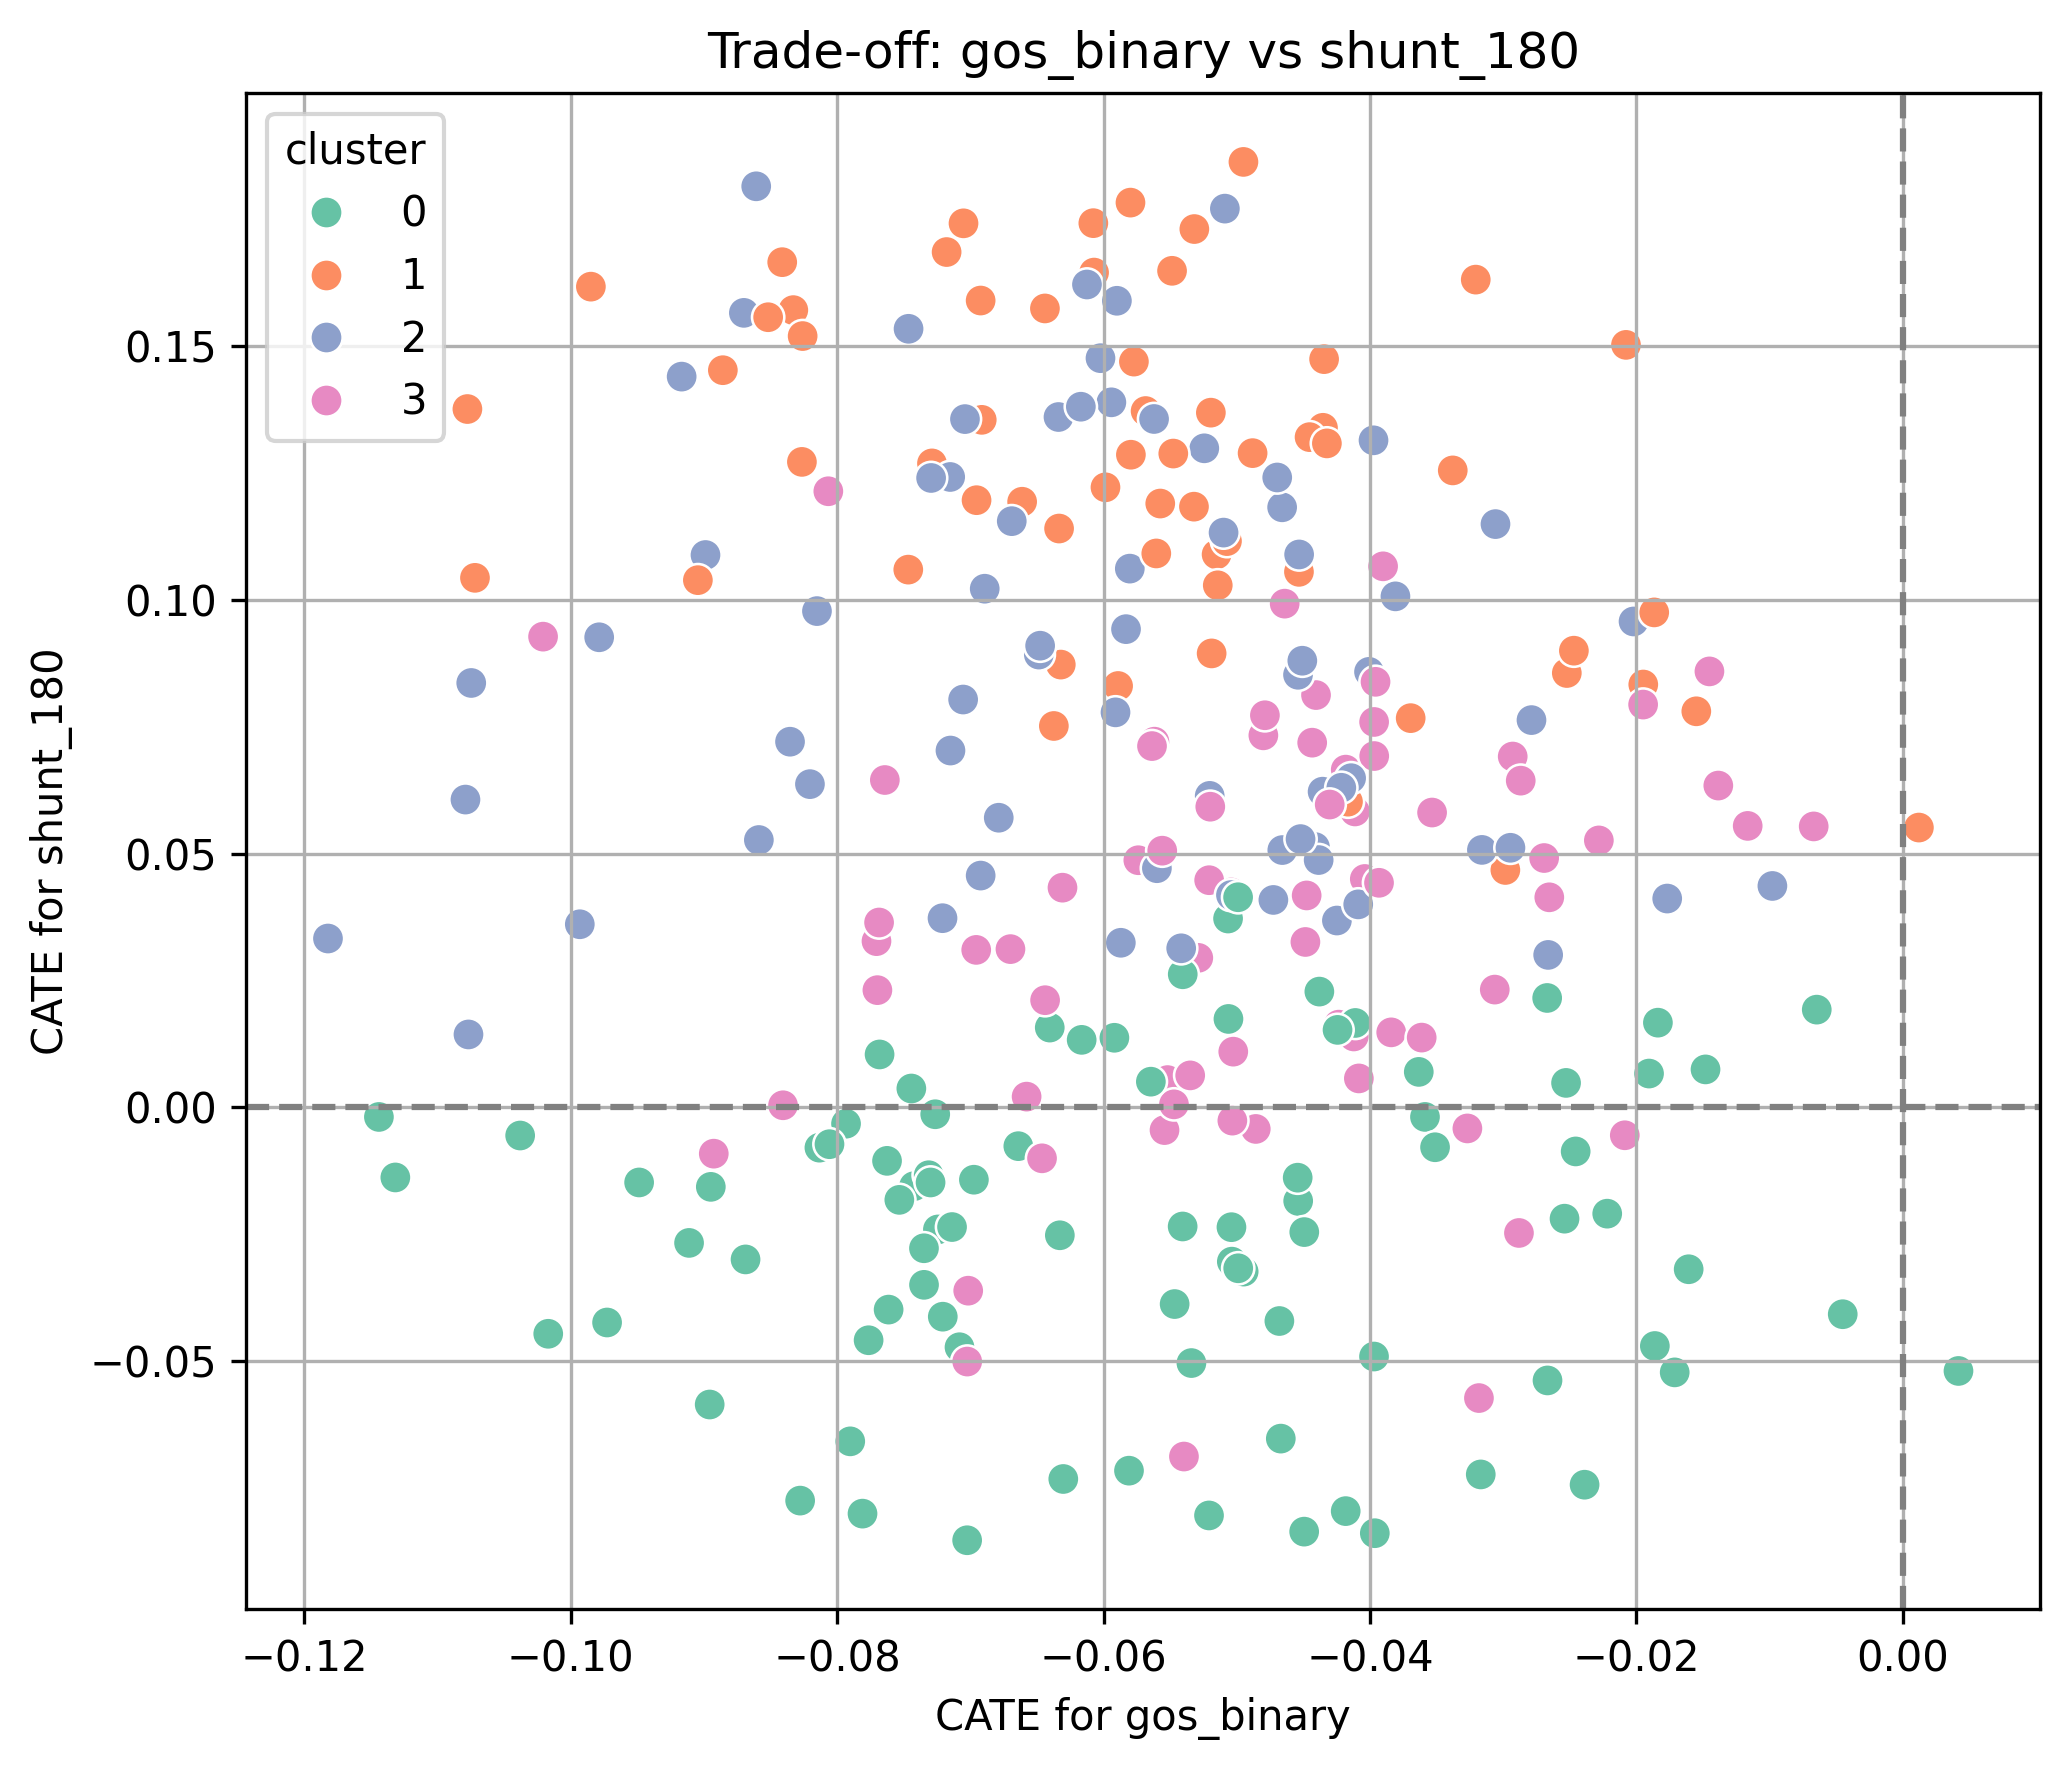

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cate_df = pd.DataFrame(cate_matrix, columns=cate_file_dict.keys())
cate_df['cluster'] = clusters

plot_cate_tradeoff(cate_df, "gos_binary", "shunt_180", clusters=cate_df['cluster'])
